# 02 · Workload, execution risk, and quality

The router uses **two different feature sets** before selecting a model: a workload head estimates how much work the trajectory will require, while an execution-risk head estimates likely friction. Their calibrated outputs feed a separate model-quality function.

In [1]:
from pathlib import Path
import csv, json, random, statistics, sys
from collections import Counter, defaultdict

ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))
from analysis_notebook_utils import *
from IPython.display import SVG, display

def read_csv(path):
    with Path(path).open(encoding="utf-8", newline="") as handle:
        return list(csv.DictReader(handle))

complexity = read_csv(ROOT / 'results/complexity_scores.csv')
test = read_csv(ROOT / 'results/two_stage_test.csv')


Held-out n: 198
Complexity MAE: 14.90
RMSE: 19.13
Correlation: 0.687
Representative trajectory: 368396b4e15ab06d-173eb6d0


## Workload head

The workload target is learned from later token growth, tool-call count, and distinct tools, but prediction uses only opening-time features.

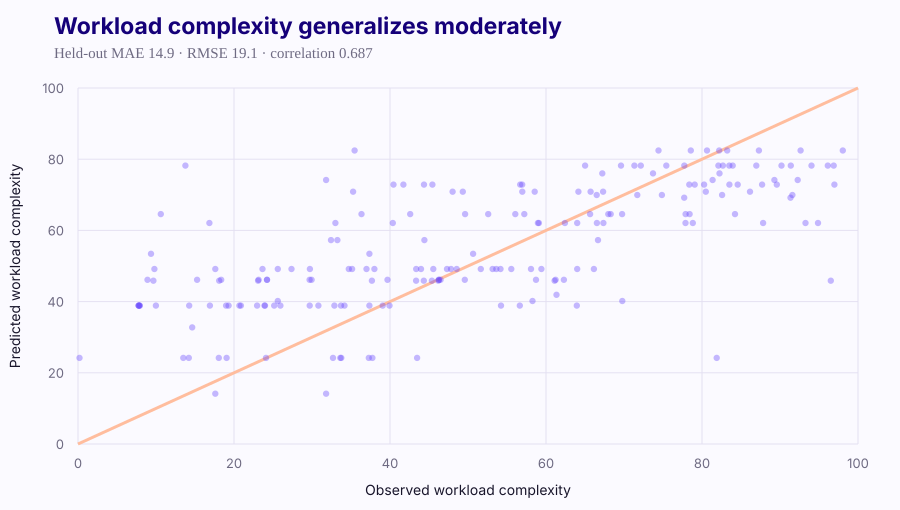

In [2]:
observed=[float(r['observed_complexity']) for r in test]
predicted=[float(r['predicted_complexity']) for r in test]
svg=scatter_chart(observed,predicted,'Workload complexity generalizes moderately','Held-out MAE 14.9 · RMSE 19.1 · correlation 0.687')
display(SVG(svg))


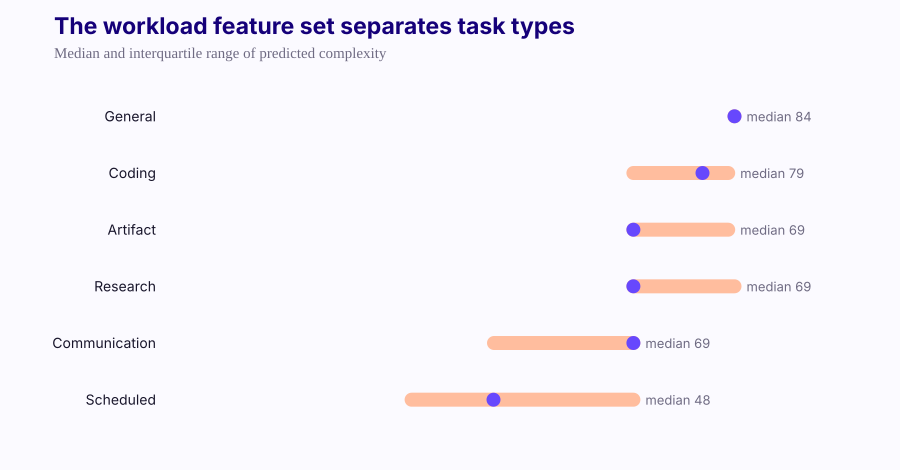

In [3]:
groups=defaultdict(list)
for r in complexity: groups[r['task_category'].title()].append(float(r['predicted_complexity']))
groups=dict(sorted(groups.items(), key=lambda item: statistics.median(item[1]), reverse=True))
display(SVG(median_iqr_chart(groups,'The workload feature set separates task types','Median and interquartile range of predicted complexity')))


## Complexity uncertainty for a given feature row

The ridge model produces a point estimate, not a probability. The distribution below is an **empirical residual bootstrap**: it adds held-out residuals to one opening request's prediction. Change `TRAJECTORY_ID` to inspect another row.

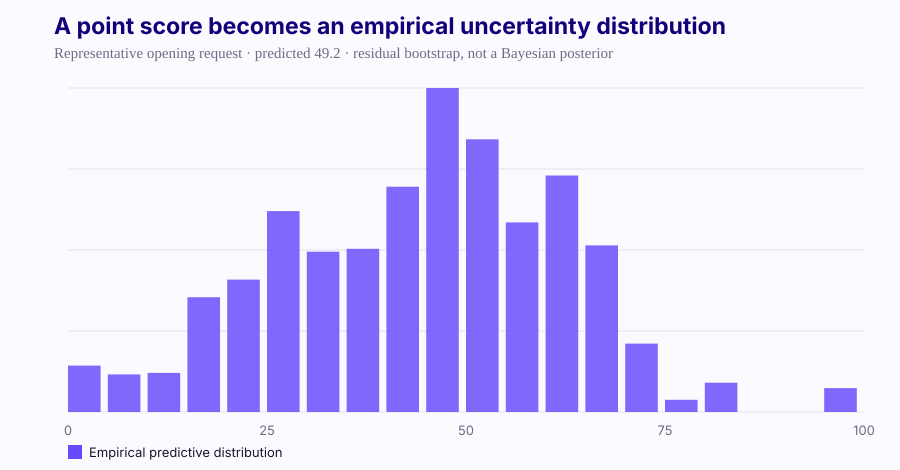

In [4]:
TRAJECTORY_ID = '368396b4e15ab06d-173eb6d0'
row = next(r for r in test if r['trajectory_id'] == TRAJECTORY_ID)
center=float(row['predicted_complexity'])
errors=[float(r['predicted_complexity'])-float(r['observed_complexity']) for r in test]
rng=random.Random(20260823)
samples=[max(0,min(100,center-rng.choice(errors))) for _ in range(5000)]
display(SVG(histogram({'Empirical predictive distribution': samples}, 'A point score becomes an empirical uncertainty distribution', f'Representative opening request · predicted {center:.1f} · residual bootstrap, not a Bayesian posterior', bins=20, x_min=0, x_max=100)))


## Quality head

The quality model combines task difficulty with a non-negative capability-prior effect. Price is excluded from quality prediction and enters only after quality has been estimated.

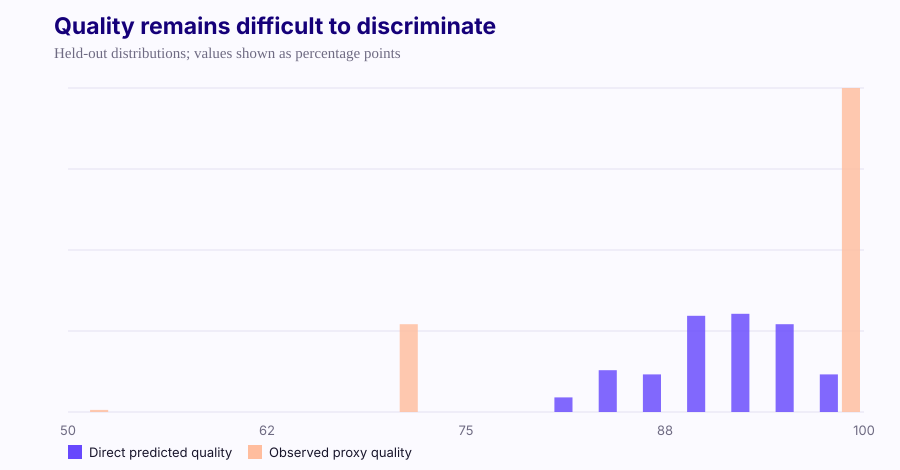

In [5]:
display(SVG(histogram({'Direct predicted quality':[float(r['direct_policy_quality'])*100 for r in test], 'Observed proxy quality':[float(r['observed_quality'])*100 for r in test]}, 'Quality remains difficult to discriminate', 'Held-out distributions; values shown as percentage points', bins=18, x_min=50, x_max=100)))


### Routing decision

For every historically supported candidate, predict quality. Keep candidates within validation-selected `epsilon = 0.025` of the best predicted quality, then choose the cheapest. If no model has comparable historical support, use the fixed Sonnet fallback.